In [1]:
#Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Importando as bibliotecas necessárias
import statsmodels.formula.api as smf

In [3]:
#Configurando o pandas para exibir todas as linhas, colunas e o conteúdo completo das células
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [4]:
#Importando a base de dados
dados = pd.read_csv('C:\\Users\\luisb\\Desktop\\BASE_DE_DADOS\\Boston.csv')

In [5]:
dados.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [6]:
dados.columns

Index(['Unnamed: 0', 'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
       'rad', 'tax', 'ptratio', 'lstat', 'medv'],
      dtype='str')

#### **O modelo regrediu medv (valor mediano dos imóveis, em $1.000) em função de lstat (% da população de baixa renda).**
A equação estimada é:

medv = 34,5538 − 0,9500 × lstat

In [ ]:
#Minimos quadrados - Simple Linear Regression
lm = smf.ols('medv~lstat', data=dados).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.08e-88
Time:                        01:11:15   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.5538      0.563     61.415      0.0

#### **O modelo prevê o valor médio dos imóveis naquele bairro, dado o nível de lstat:**

A cada aumento de 1 ponto percentual em lstat, o preço cai em média $950 (coeficiente = −0,95)
Então de lstat=5 para lstat=10 (+5 pontos), a queda esperada é: 5 × $950 = $4.750 → confirmado: 29.803 − 25.053 ≈ $4.750 ✅

Atenção ao contexto do modelo:
R² = 0,544 → lstat explica ~54% da variação nos preços, razoável mas não excelente


#### **Resultados do predict para lstat = 5, 10 e 15:**

-Bairro com apenas 5% de baixa renda → imóveis valem ~$29.800
-Bairro com 10% de baixa renda → imóveis valem ~$25.050
-Bairro com 15% de baixa renda → imóveis valem ~$20.300


In [8]:
#Fazendo previsões para dados novos:
lm.predict(pd.DataFrame({'lstat': [5, 10, 15]}))

0    29.803594
1    25.053347
2    20.303101
dtype: float64

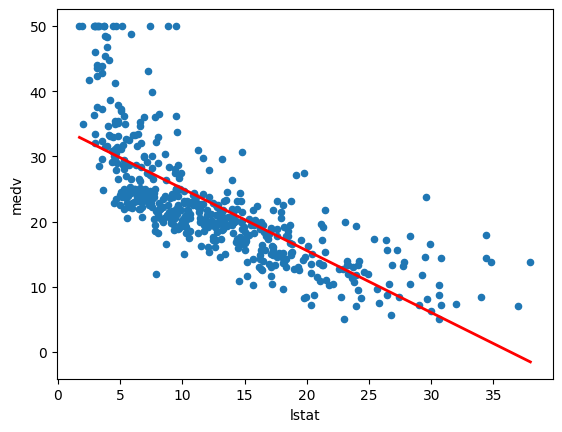

In [9]:
x_new = pd.DataFrame({'lstat': [dados.lstat.min(), dados.lstat.max()]})
preds = lm.predict(x_new)
dados.plot(kind='scatter', x='lstat', y='medv')
plt.plot(x_new, preds, c='red', linewidth=2)
plt.show()

In [10]:
#Minimos quadrados - Multiple Linear Regression
lm = smf.ols('medv~lstat+age', data=dados).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     309.0
Date:                Sat, 23 May 2026   Prob (F-statistic):           2.98e-88
Time:                        01:24:21   Log-Likelihood:                -1637.5
No. Observations:                 506   AIC:                             3281.
Df Residuals:                     503   BIC:                             3294.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.2228      0.731     45.458      0.0

In [11]:
#Minimos quadrados - Multiple Linear Regression
#Usando todas as variaveis preditoras
features_to_use = [feature for feature in dados.columns if feature != 'medv']
formula = 'medv ~ ' + ' + '.join(features_to_use)
lm = smf.ols(formula, data=dados).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     113.5
Date:                Sat, 23 May 2026   Prob (F-statistic):          2.23e-133
Time:                        01:26:42   Log-Likelihood:                -1504.9
No. Observations:                 506   AIC:                             3036.
Df Residuals:                     493   BIC:                             3091.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.6173      4.936      8.431      0.0

#### **Interpretação do Modelo com Interação lstat * age**
O modelo agora é: medv = 36,09 − 1,39·lstat − 0,0007·age + 0,0042·(lstat×age)

20 anos -> −1,39 + 0,08 = −1,31 Preço cai $1.310 por 1% a mais de lstat

In [12]:
#Interações entre variáveis preditoras
lm = smf.ols('medv~lstat*age', data=dados).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     209.3
Date:                Sat, 23 May 2026   Prob (F-statistic):           4.86e-88
Time:                        01:29:23   Log-Likelihood:                -1635.0
No. Observations:                 506   AIC:                             3278.
Df Residuals:                     502   BIC:                             3295.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.0885      1.470     24.553      0.0

In [13]:
#Importando a base de dados
dados2 = pd.read_csv('C:\\Users\\luisb\\Desktop\\BASE_DE_DADOS\\Carseats.csv')

In [16]:
lm = smf.ols('Sales ~ Income + Price + Advertising+ C(ShelveLoc) + C(US)', data=dados2).fit()
print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     110.1
Date:                Sat, 23 May 2026   Prob (F-statistic):           5.24e-81
Time:                        01:42:45   Log-Likelihood:                -785.09
No. Observations:                 400   AIC:                             1584.
Df Residuals:                     393   BIC:                             1612.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 10

2. Interpretação de Cada Variável
🔵 Intercept = 10,4179 ✅ (p = 0,000)
Valor base das vendas quando todas as variáveis numéricas são zero e as categorias estão na referência (ShelveLoc = Bad, US = No). Representa ~10.418 unidades vendidas na baseline.

🟢 C(ShelveLoc)[T.Good] = +4,8381 ✅ (p = 0,000)

Prateleira Good vende em média 4.838 unidades a mais que prateleira Bad (referência)
Maior impacto do modelo — localização na prateleira é o fator mais importante

🟢 C(ShelveLoc)[T.Medium] = +1,8907 ✅ (p = 0,000)

Prateleira Medium vende em média 1.891 unidades a mais que prateleira Bad
Efeito positivo mas bem menor que Good


Ranking de prateleira: Bad < Medium < Good — confirma o senso comum do varejo


🔴 C(US)[T.Yes] = −0,1237 ❌ (p = 0,622)

Loja estar nos EUA não tem efeito significativo sobre as vendas
p = 0,622 >> 0,05 → variável não significativa, poderia ser removida do modelo


🟢 Income = +0,0139 ✅ (p = 0,000)

A cada $1.000 a mais na renda da comunidade, as vendas sobem em média 13,9 unidades
Efeito positivo e significativo — comunidades mais ricas compram mais


🟢 Price = −0,0570 ✅ (p = 0,000)

A cada $1 a mais no preço, as vendas caem em média 57 unidades
Faz sentido econômico: preço mais alto = menos vendas
Segundo maior impacto numérico do modelo


🟢 Advertising = +0,1117 ✅ (p = 0,000)

A cada $1.000 a mais em publicidade, as vendas sobem em média 111,7 unidades
Investir em propaganda tem retorno positivo e significativo

